# **Experiments on My MAMBA Model**

**IMPORTS**

In [1]:
import torch
import os, sys, time, copy, pickle as pkl
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('dark')
%matplotlib inline
from model.parallel_scan import pscan
torch.manual_seed(0)

**COMPARING PARALLEL AND SEQUENTIAL IMPLEMENTATION OF SELECTIVE SCAN**

In [7]:
# Dummy Problem
B, L, D, N = 2, 16, 4, 3
A = torch.rand(B, L, D, N, requires_grad=True)
X = torch.rand(B, L, D, N, requires_grad=True)

# Parallel implementation
Y_par = pscan(A, X)
loss_par = Y_par.sum()
loss_par.backward()
gradA_par = A.grad.clone()
gradX_par = X.grad.clone()

# Sequential implementation
A_seq = A.detach().clone().requires_grad_(True)
X_seq = X.detach().clone().requires_grad_(True)
state = torch.zeros(B, D, N)
outputs = []
for t in range(L):
    state = A_seq[:, t] * state + X_seq[:, t]
    outputs.append(state)
Y_seq = torch.stack(outputs, dim=1)
loss_seq = Y_seq.sum()
loss_seq.backward()
gradA_seq = A_seq.grad
gradX_seq = X_seq.grad

# Forward check
forward_diff = (Y_par - Y_seq).abs()
print("Forward:")
print(f"  max abs error  = {forward_diff.max().item():.3e}")
print(f"  mean abs error = {forward_diff.mean().item():.3e}")

# Gradient check: A
gradA_diff = (gradA_par - gradA_seq).abs()
print("\nGradient w.r.t. A:")
print(f"  max abs error  = {gradA_diff.max().item():.3e}")
print(f"  mean abs error = {gradA_diff.mean().item():.3e}")
# Gradient check: X
gradX_diff = (gradX_par - gradX_seq).abs()

print("\nGradient w.r.t. X:")
print(f"  max abs error  = {gradX_diff.max().item():.3e}")
print(f"  mean abs error = {gradX_diff.mean().item():.3e}")

# Overall
tol = 1e-6

print("\nChecks:")
print("  Forward :", torch.allclose(Y_par, Y_seq, atol=tol, rtol=tol))
print("  Grad A  :", torch.allclose(gradA_par, gradA_seq, atol=tol, rtol=tol))
print("  Grad X  :", torch.allclose(gradX_par, gradX_seq, atol=tol, rtol=tol))

Forward:
  max abs error  = 2.384e-07
  mean abs error = 2.291e-08

Gradient w.r.t. A:
  max abs error  = 4.768e-07
  mean abs error = 5.545e-08

Gradient w.r.t. X:
  max abs error  = 4.768e-07
  mean abs error = 3.943e-08

Checks:
  Forward : True
  Grad A  : True
  Grad X  : True


**PLOTTING TRAINING AND VALIDATION CURVES ACROSS VARYING HYPERPARAMETER SETTINGS**

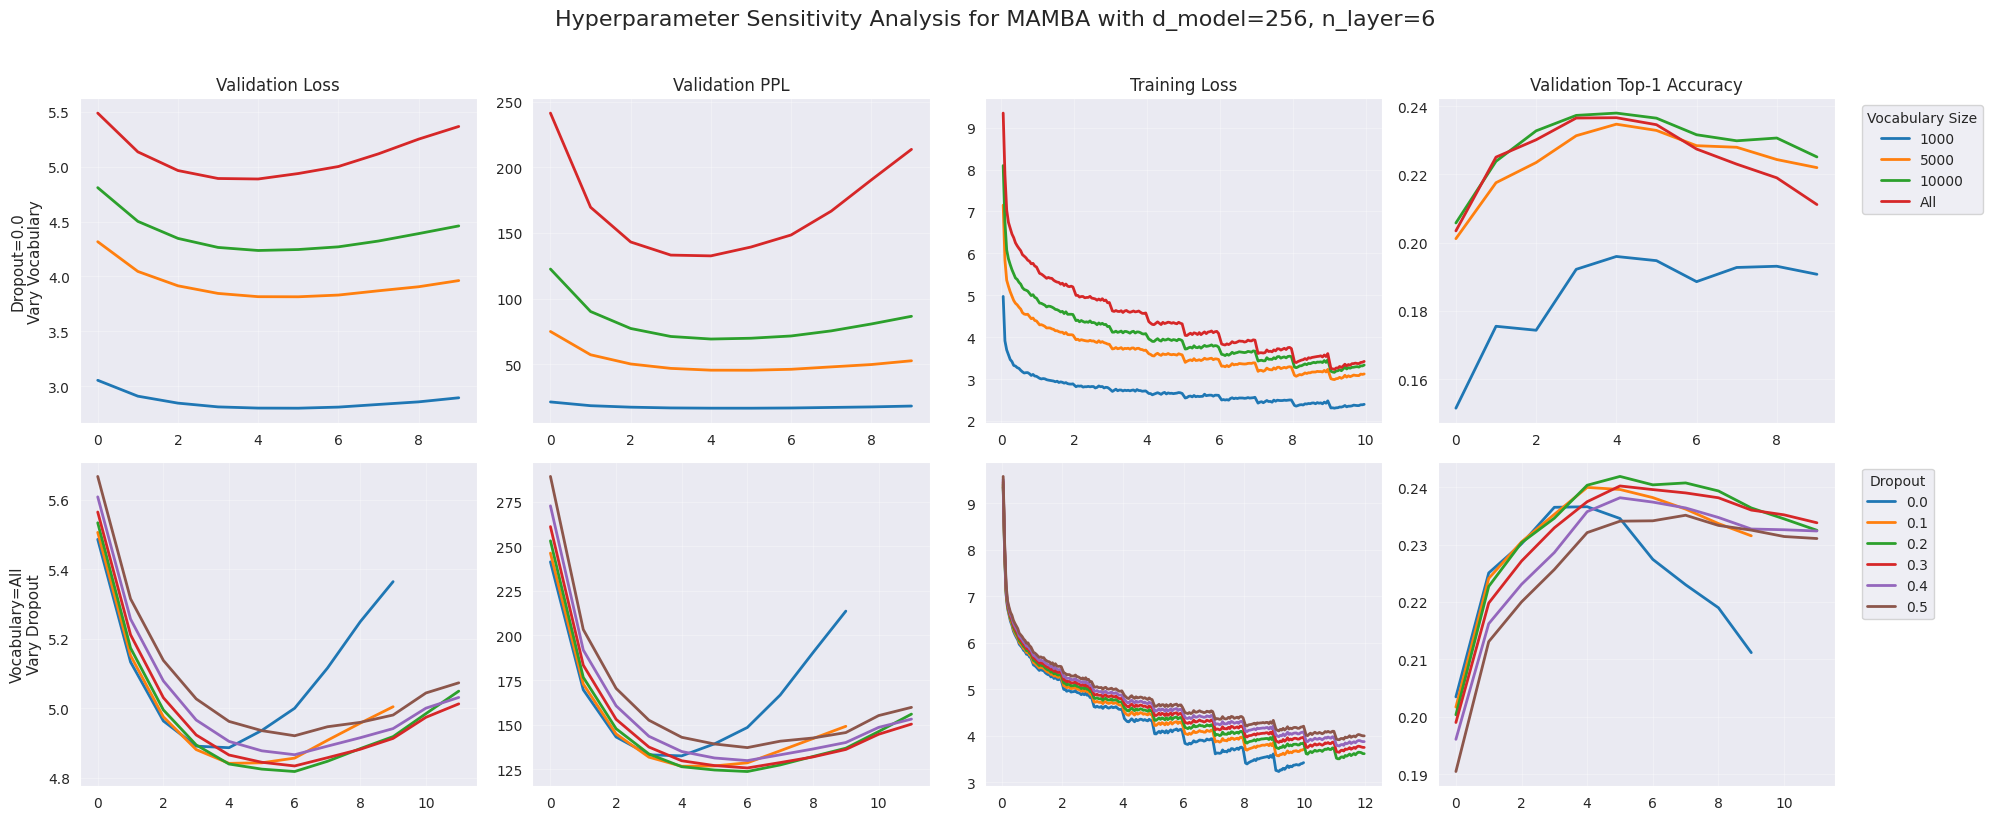

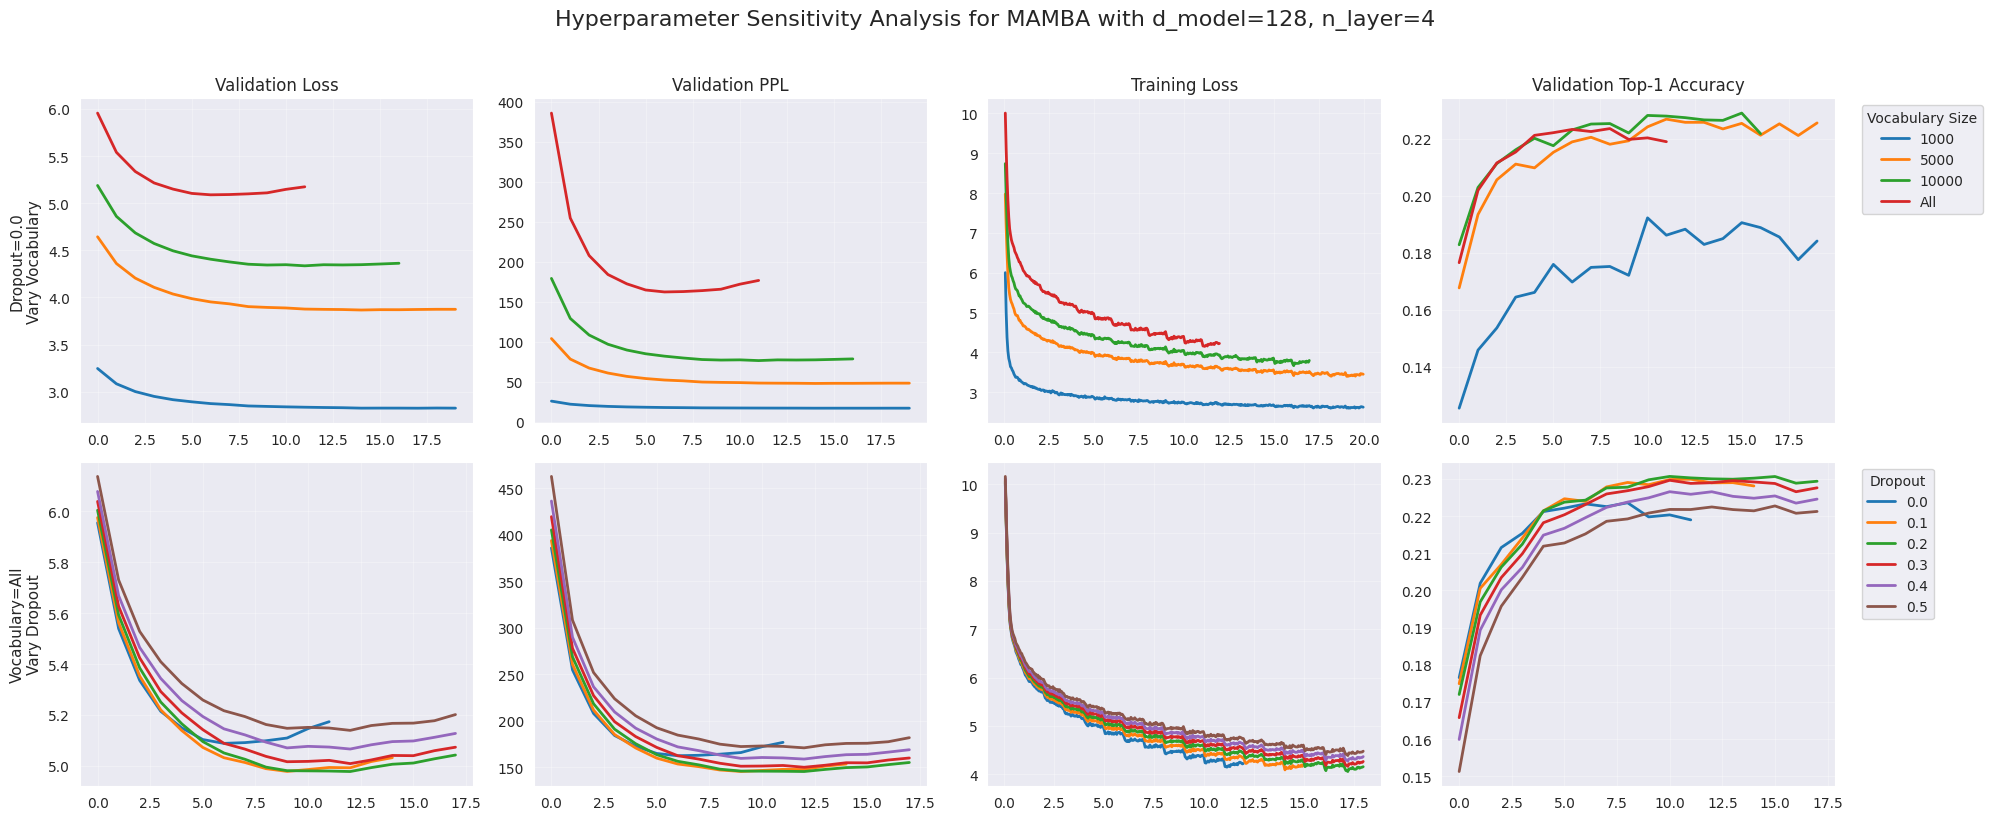

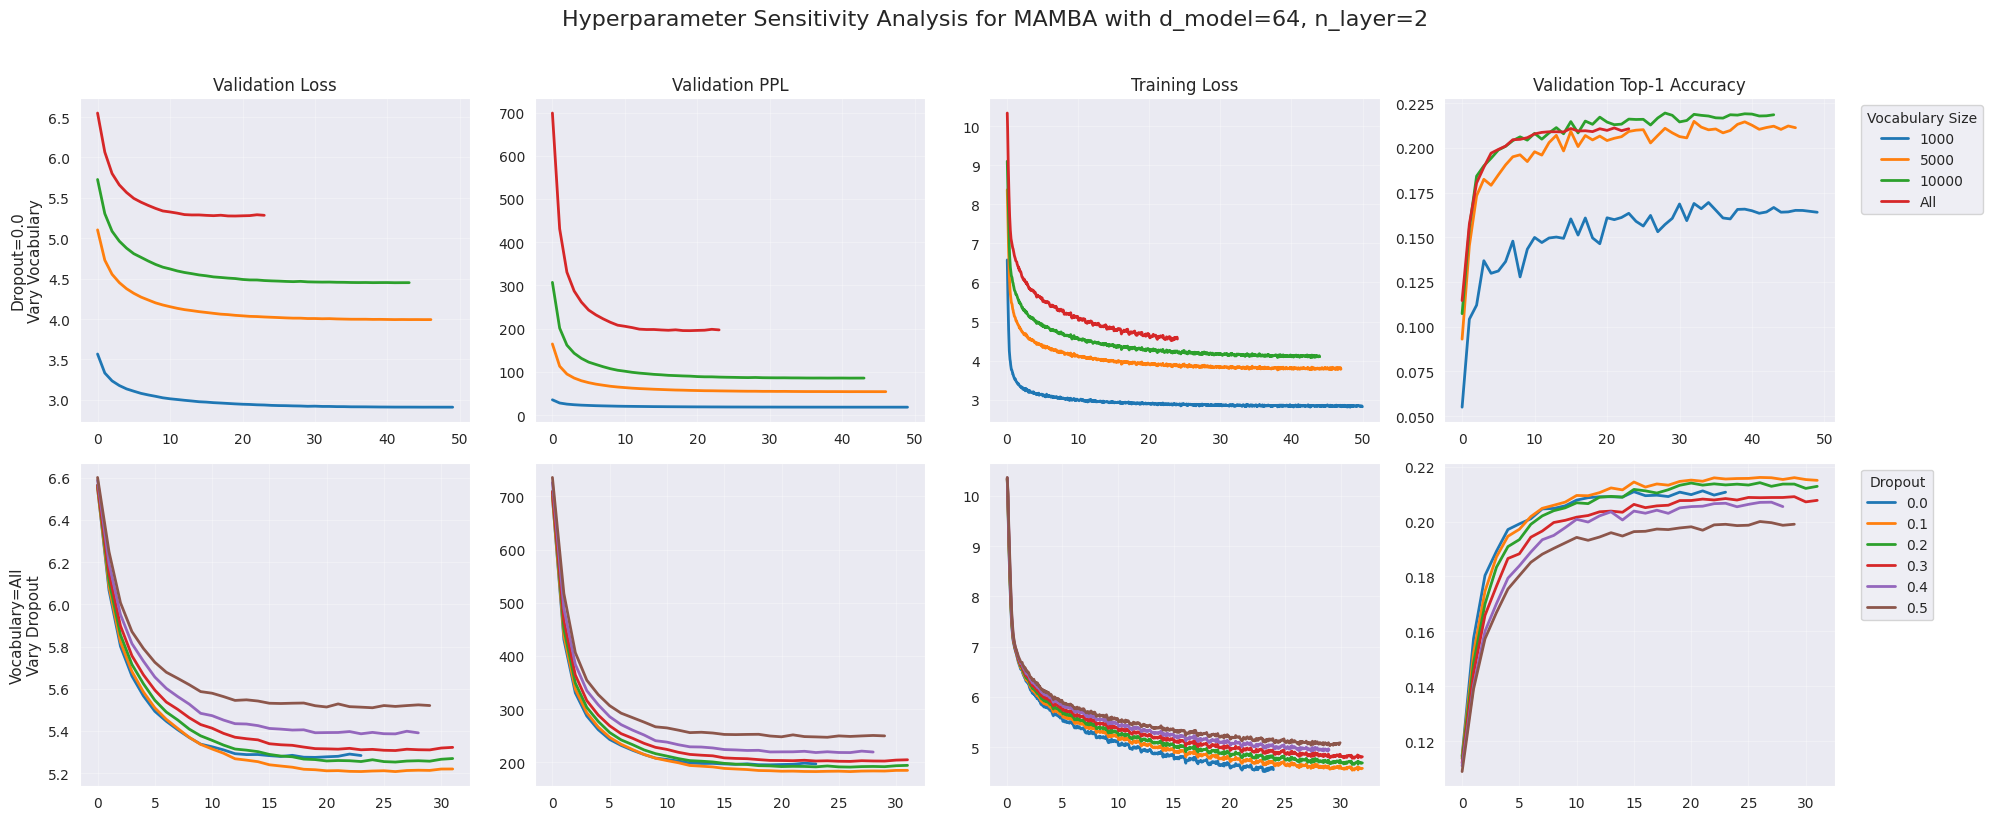

In [17]:
results_path = "experiments"
architectures = {
    0: "d_model=256, n_layer=6",
    1: "d_model=128, n_layer=4",
    2: "d_model=64, n_layer=2",
}
vocab_sizes = [1000, 5000, 10000, -1]
dropouts = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
metrics = [
    ("loss", "Validation Loss"),
    ("ppl", "Validation PPL"),
    ("train_loss", "Training Loss"),
    ("accuracy_top1", "Validation Top-1 Accuracy"),
]

hp_map = {}
exp = 1
for vocab in vocab_sizes:
    for dropout in dropouts:
        hp_map[(vocab, dropout)] = exp
        exp += 1

for arch_idx in range(3):

    fig, axes = plt.subplots(2,len(metrics),figsize=(20, 8),squeeze=False)
    arch_dir = os.path.join(results_path,str(arch_idx),"logs")

    # ROW 1: Fix dropout = 0.0, Vary vocabulary size
    fixed_dropout = 0.0
    for vocab_size in vocab_sizes:
        local_exp = hp_map[(vocab_size, fixed_dropout)]
        global_exp = arch_idx * 24 + local_exp
        train_file = os.path.join(arch_dir,f"exp_{global_exp:03d}.log_train.csv")
        val_file = os.path.join(arch_dir,f"exp_{global_exp:03d}.log_val.csv")
        train_df = pd.read_csv(train_file)
        val_df = pd.read_csv(val_file)
        label = ("All"if vocab_size == -1 else str(vocab_size))
        for col, (metric, title) in enumerate(metrics):
            ax = axes[0, col]
            if metric == "train_loss":
                ax.plot(train_df["epoch"],train_df["loss"],label=label,linewidth=2,)
            else:
                ax.plot(val_df["epoch"],val_df[metric],label=label,linewidth=2,)
            ax.set_title(title)
            ax.grid(True, alpha=0.3)

    # ROW 2: Fix vocab_size = -1, Vary dropout
    fixed_vocab = -1
    for dropout in dropouts:
        local_exp = hp_map[(fixed_vocab, dropout)]
        global_exp = arch_idx * 24 + local_exp
        train_file = os.path.join(arch_dir,f"exp_{global_exp:03d}.log_train.csv")
        val_file = os.path.join(arch_dir,f"exp_{global_exp:03d}.log_val.csv")
        train_df = pd.read_csv(train_file)
        val_df = pd.read_csv(val_file)
        label = f"{dropout:.1f}"
        for col, (metric, title) in enumerate(metrics):
            ax = axes[1, col]
            if metric == "train_loss":
                ax.plot(train_df["epoch"],train_df["loss"],label=label,linewidth=2,)
            else:
                ax.plot(val_df["epoch"],val_df[metric],label=label,linewidth=2,)
            ax.grid(True, alpha=0.3)

    # Row labels
    axes[0, 0].set_ylabel("Dropout=0.0\nVary Vocabulary",fontsize=11)
    axes[1, 0].set_ylabel("Vocabulary=All\nVary Dropout",fontsize=11)
    # Legends
    axes[0, -1].legend(title="Vocabulary Size",bbox_to_anchor=(1.05, 1),loc="upper left")
    axes[1, -1].legend(title="Dropout",bbox_to_anchor=(1.05, 1),loc="upper left")

    fig.suptitle(f"Hyperparameter Sensitivity Analysis for MAMBA with"f" {architectures[arch_idx]}",fontsize=16,y=1.02)
    plt.tight_layout()
    plt.show()